# 🫀 Cardiovascular Disease Prediction — Full ML Pipeline
**Dataset:** 70,000 patients | **Target:** `cardio` (0 = No Disease, 1 = Has Disease)

---
### Pipeline Steps
1. Load Data
2. Data Cleaning
3. Feature Engineering
4. EDA & Visualizations
5. Preprocessing
6. Model Training (6 models)
7. Ensemble (Voting Classifier)
8. Results & Evaluation


## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, roc_auc_score, roc_curve,
                              precision_recall_curve, average_precision_score,
                              f1_score)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               VotingClassifier)
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# ── Styling ──────────────────────────────────────────────────────────────────
PALETTE    = ['#2ECC71', '#E74C3C']
BG_COLOR   = '#0F1117'
CARD_COLOR = '#1A1D2E'
ACCENT     = '#3498DB'
TEXT_COLOR = '#ECF0F1'
GRID_COLOR = '#2C3E50'

plt.rcParams.update({
    'figure.facecolor' : BG_COLOR,
    'axes.facecolor'   : CARD_COLOR,
    'axes.edgecolor'   : GRID_COLOR,
    'axes.labelcolor'  : TEXT_COLOR,
    'xtick.color'      : TEXT_COLOR,
    'ytick.color'      : TEXT_COLOR,
    'text.color'       : TEXT_COLOR,
    'grid.color'       : GRID_COLOR,
    'grid.alpha'       : 0.4,
    'axes.titlesize'   : 13,
    'axes.labelsize'   : 11,
})

print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


## 2. Load Data

In [3]:
df = pd.read_csv('cardio_train.csv', sep=';')

print(f"Shape        : {df.shape}")
print(f"Missing vals : {df.isnull().sum().sum()}")
print()
display(df.head())
display(df.describe())


Shape        : (70000, 13)
Missing vals : 0



,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,28851.302323,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,25006.750000,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,50001.500000,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,74889.250000,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


## 3. Data Cleaning

Steps:
- Convert `age` from days → years
- Engineer `bmi`, `pulse_pressure`, `map_pressure`
- Remove physiologically impossible blood pressure values
- Remove outliers using 3σ rule for height, weight, bmi


In [4]:
raw_rows = len(df)

# Age: days → years
df['age_years'] = (df['age'] / 365).round(1)
print(f"Age range: {df['age_years'].min():.0f} – {df['age_years'].max():.0f} years")

# BMI
df['bmi'] = (df['weight'] / (df['height'] / 100) ** 2).round(2)

# Blood pressure: remove impossible values
before = len(df)
df = df[(df['ap_hi'] >= 60)  & (df['ap_hi'] <= 250)]
df = df[(df['ap_lo'] >= 40)  & (df['ap_lo'] <= 200)]
df = df[df['ap_hi'] > df['ap_lo']]
print(f"BP outliers removed     : {before - len(df):,} rows")

# Height / Weight / BMI: 3σ rule
for col in ['height', 'weight', 'bmi']:
    lo = df[col].mean() - 3 * df[col].std()
    hi = df[col].mean() + 3 * df[col].std()
    before = len(df)
    df = df[(df[col] >= lo) & (df[col] <= hi)]
    print(f"{col:8s} outliers removed: {before - len(df):,} rows")

# Derived features
df['pulse_pressure'] = df['ap_hi'] - df['ap_lo']
df['map_pressure']   = (df['ap_hi'] + 2 * df['ap_lo']) / 3

# Drop original age and id
df.drop(columns=['id', 'age'], inplace=True)

print(f"\nTotal rows removed : {raw_rows - len(df):,}")
print(f"Final dataset size : {len(df):,}")
display(df.head())


Age range: 30 – 65 years
BP outliers removed     : 1,328 rows
height   outliers removed: 287 rows
weight   outliers removed: 699 rows
bmi      outliers removed: 605 rows

Total rows removed : 2,919
Final dataset size : 67,081


,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,bmi,pulse_pressure,map_pressure
0,2,168,62.0,110,80,1,1,0,0,1,0,50.4,21.97,30,90.000000
1,1,156,85.0,140,90,3,1,0,0,1,1,55.4,34.93,50,106.666667
2,1,165,64.0,130,70,3,1,0,0,0,1,51.7,23.51,60,90.000000
3,2,169,82.0,150,100,1,1,0,0,1,1,48.3,28.71,50,116.666667
4,1,156,56.0,100,60,1,1,0,0,0,0,47.9,23.01,40,73.333333


## 4. EDA — Overview (Target, Age, BMI)

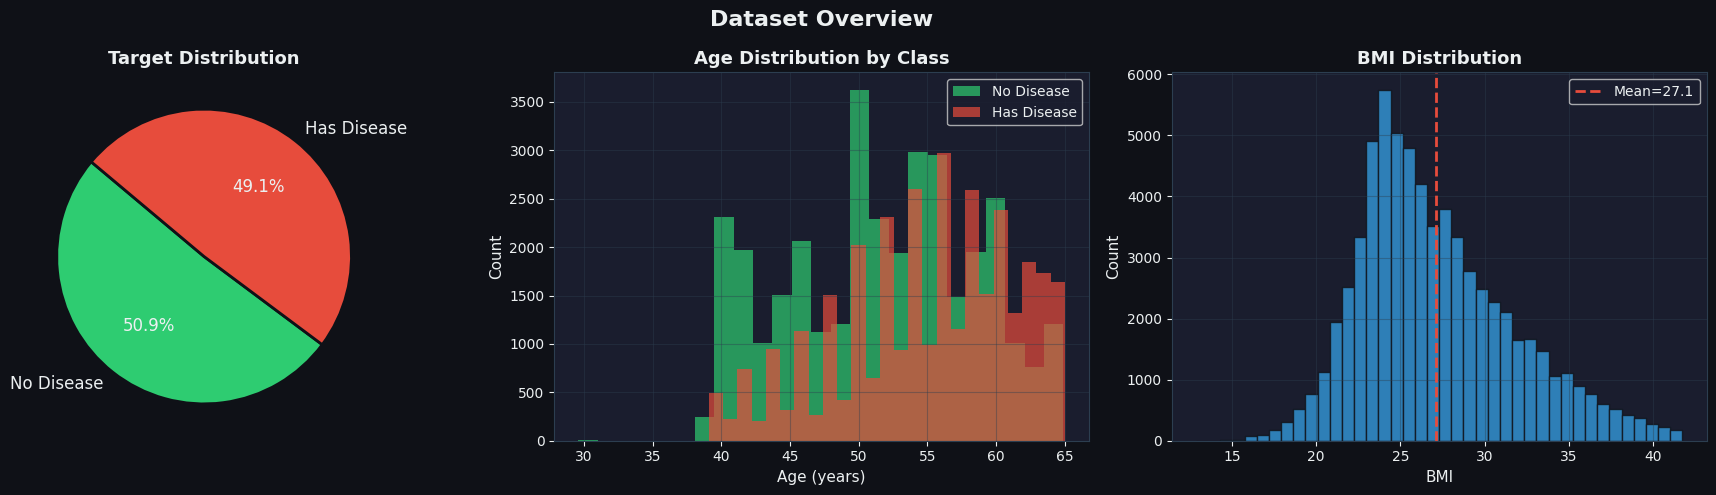

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor(BG_COLOR)
fig.suptitle('Dataset Overview', fontsize=16, fontweight='bold', color=TEXT_COLOR)

# Target pie
counts = df['cardio'].value_counts()
axes[0].pie(counts, labels=['No Disease', 'Has Disease'],
            colors=PALETTE, autopct='%1.1f%%', startangle=140,
            textprops={'color': TEXT_COLOR, 'fontsize': 12},
            wedgeprops={'edgecolor': BG_COLOR, 'linewidth': 2})
axes[0].set_title('Target Distribution', fontweight='bold')

# Age histogram
for label, color in zip([0, 1], PALETTE):
    axes[1].hist(df[df['cardio'] == label]['age_years'], bins=25,
                 alpha=0.7, label=['No Disease', 'Has Disease'][label], color=color)
axes[1].set_xlabel('Age (years)'); axes[1].set_ylabel('Count')
axes[1].set_title('Age Distribution by Class', fontweight='bold')
axes[1].legend(); axes[1].grid(True)

# BMI
axes[2].hist(df['bmi'], bins=40, color=ACCENT, alpha=0.8, edgecolor=BG_COLOR)
axes[2].axvline(df['bmi'].mean(), color='#E74C3C', linestyle='--', lw=2,
                label=f'Mean={df["bmi"].mean():.1f}')
axes[2].set_xlabel('BMI'); axes[2].set_ylabel('Count')
axes[2].set_title('BMI Distribution', fontweight='bold')
axes[2].legend(); axes[2].grid(True)

plt.tight_layout()
plt.show()


## 4.2. Correlation Heatmap

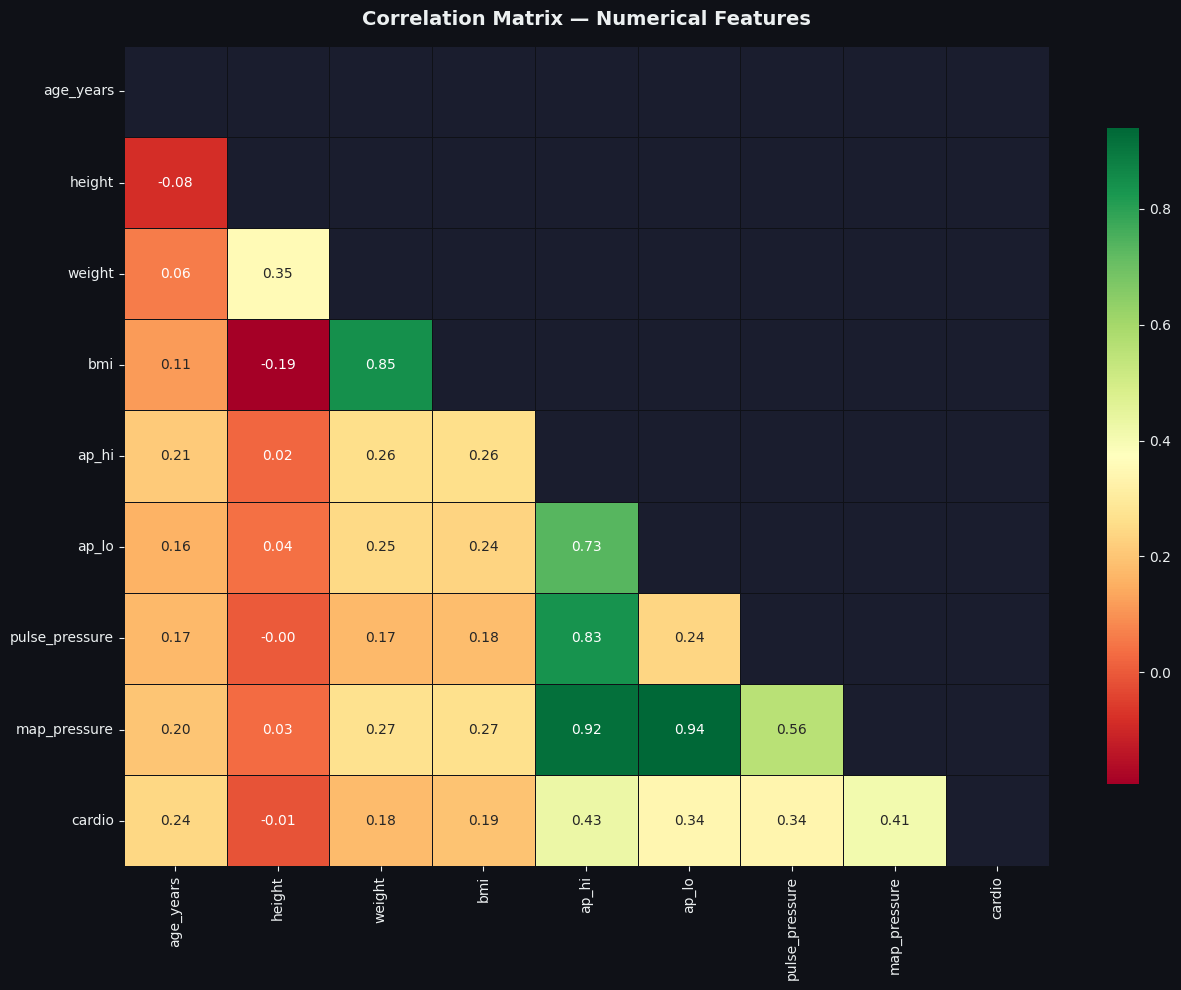

In [6]:
fig, ax = plt.subplots(figsize=(13, 10))
fig.patch.set_facecolor(BG_COLOR)

num_cols = ['age_years','height','weight','bmi','ap_hi','ap_lo',
            'pulse_pressure','map_pressure','cardio']
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            ax=ax, linewidths=0.5, linecolor=BG_COLOR,
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix — Numerical Features',
             fontweight='bold', fontsize=14, color=TEXT_COLOR, pad=15)
plt.tight_layout()
plt.show()


## 4.3. Categorical Features vs Disease

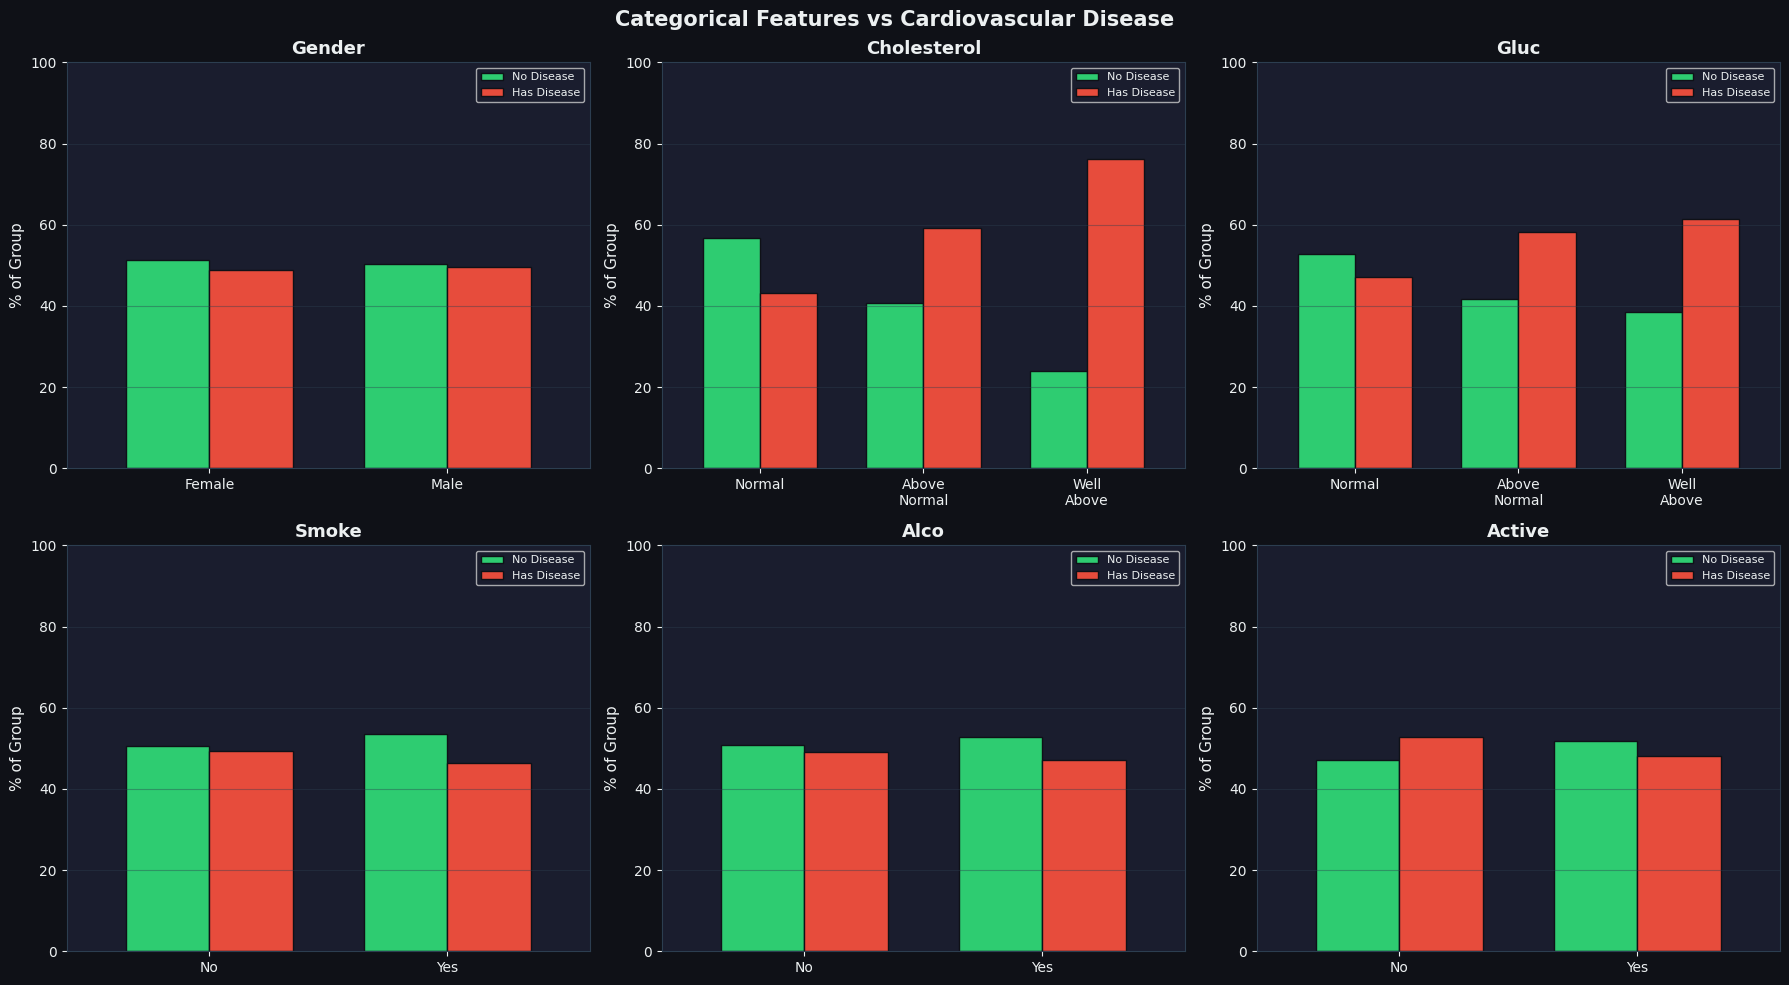

In [7]:
cat_features = {
    'gender'     : {1: 'Female', 2: 'Male'},
    'cholesterol': {1: 'Normal', 2: 'Above\nNormal', 3: 'Well\nAbove'},
    'gluc'       : {1: 'Normal', 2: 'Above\nNormal', 3: 'Well\nAbove'},
    'smoke'      : {0: 'No', 1: 'Yes'},
    'alco'       : {0: 'No', 1: 'Yes'},
    'active'     : {0: 'No', 1: 'Yes'},
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.patch.set_facecolor(BG_COLOR)
fig.suptitle('Categorical Features vs Cardiovascular Disease',
             fontsize=15, fontweight='bold', color=TEXT_COLOR)

for ax, (feat, labels) in zip(axes.flat, cat_features.items()):
    ct = df.groupby([feat, 'cardio']).size().unstack(fill_value=0)
    ct.index = [labels.get(i, str(i)) for i in ct.index]
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    ct_pct.plot(kind='bar', ax=ax, color=PALETTE, edgecolor=BG_COLOR,
                width=0.7, legend=False)
    ax.set_title(feat.capitalize(), fontweight='bold')
    ax.set_ylabel('% of Group'); ax.set_ylim(0, 100)
    ax.set_xticklabels(ct_pct.index, rotation=0)
    ax.grid(True, axis='y', alpha=0.4)
    ax.legend(['No Disease', 'Has Disease'], fontsize=8)

plt.tight_layout()
plt.show()


## 4.4. Scatter Analysis — Blood Pressure & BMI

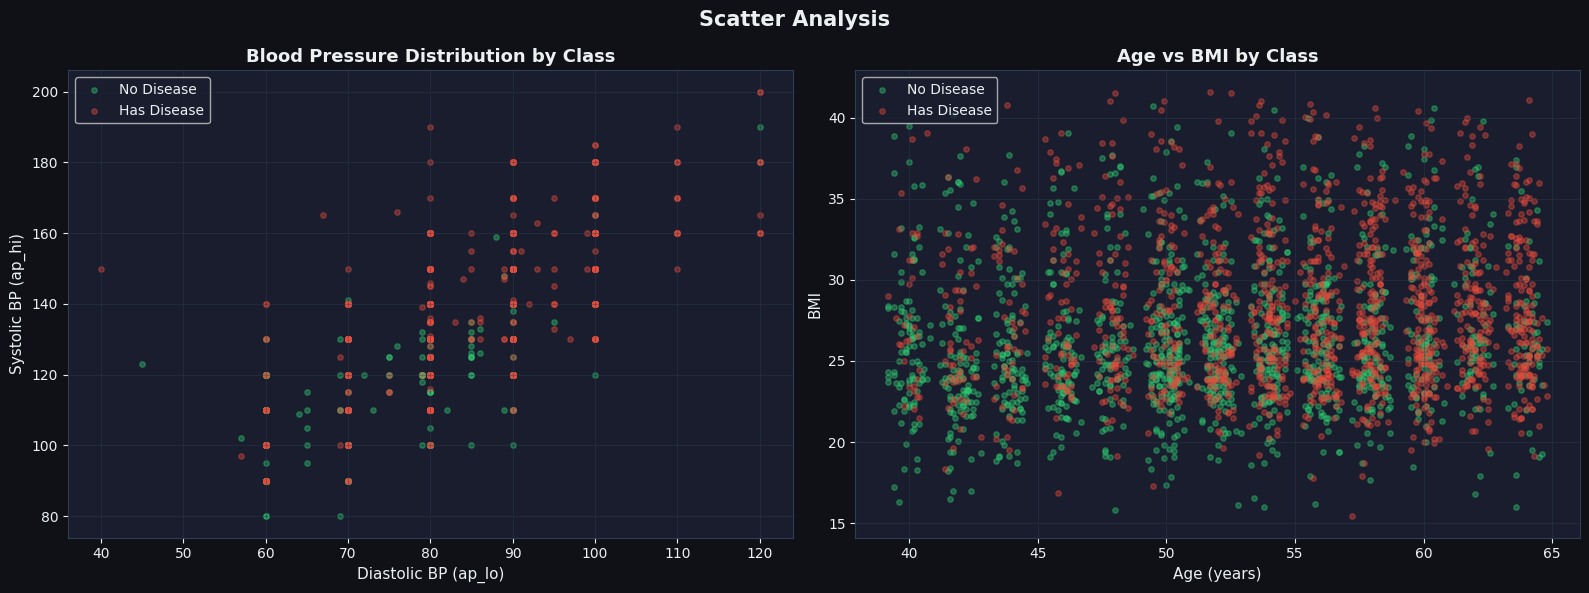

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor(BG_COLOR)
sample = df.sample(3000, random_state=42)

for label, color, name in zip([0, 1], PALETTE, ['No Disease', 'Has Disease']):
    sub = sample[sample['cardio'] == label]
    axes[0].scatter(sub['ap_lo'], sub['ap_hi'], alpha=0.4, s=15,
                    color=color, label=name)
axes[0].set_xlabel('Diastolic BP (ap_lo)'); axes[0].set_ylabel('Systolic BP (ap_hi)')
axes[0].set_title('Blood Pressure Distribution by Class', fontweight='bold')
axes[0].legend(); axes[0].grid(True)

for label, color, name in zip([0, 1], PALETTE, ['No Disease', 'Has Disease']):
    sub = sample[sample['cardio'] == label]
    axes[1].scatter(sub['age_years'], sub['bmi'], alpha=0.4, s=15,
                    color=color, label=name)
axes[1].set_xlabel('Age (years)'); axes[1].set_ylabel('BMI')
axes[1].set_title('Age vs BMI by Class', fontweight='bold')
axes[1].legend(); axes[1].grid(True)

plt.suptitle('Scatter Analysis', fontsize=15, fontweight='bold', color=TEXT_COLOR)
plt.tight_layout()
plt.show()


## 5. Preprocessing — Train/Test Split & Scaling

In [9]:
FEATURES = ['age_years','gender','height','weight','bmi',
            'ap_hi','ap_lo','pulse_pressure','map_pressure',
            'cholesterol','gluc','smoke','alco','active']
TARGET   = 'cardio'

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train size : {X_train.shape}")
print(f"Test  size : {X_test.shape}")
print(f"Class balance (train): {y_train.value_counts().to_dict()}")


Train size : (53664, 14)
Test  size : (13417, 14)
Class balance (train): {0: 27322, 1: 26342}


## 6. Model Training — 6 Algorithms

In [10]:
models = {
    'Logistic Regression' : (LogisticRegression(max_iter=1000, random_state=42), True),
    'K-Nearest Neighbors' : (KNeighborsClassifier(n_neighbors=9), True),
    'Random Forest'       : (RandomForestClassifier(n_estimators=200, max_depth=10,
                              min_samples_leaf=4, random_state=42, n_jobs=-1), False),
    'Gradient Boosting'   : (GradientBoostingClassifier(n_estimators=150,
                              learning_rate=0.1, max_depth=5, random_state=42), False),
    'XGBoost'             : (XGBClassifier(n_estimators=200, learning_rate=0.05,
                              max_depth=6, subsample=0.8, colsample_bytree=0.8,
                              use_label_encoder=False, eval_metric='logloss',
                              random_state=42, n_jobs=-1), False),
    'LightGBM'            : (LGBMClassifier(n_estimators=200, learning_rate=0.05,
                              num_leaves=63, random_state=42, n_jobs=-1,
                              verbose=-1), False),
}

results = {}

for name, (model, needs_scaled) in models.items():
    Xtr = X_train_sc if needs_scaled else X_train.values
    Xte = X_test_sc  if needs_scaled else X_test.values

    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)
    y_prob = model.predict_proba(Xte)[:, 1]

    results[name] = {
        'model'   : model,
        'scaled'  : needs_scaled,
        'acc'     : accuracy_score(y_test, y_pred),
        'roc_auc' : roc_auc_score(y_test, y_prob),
        'f1'      : f1_score(y_test, y_pred),
        'y_pred'  : y_pred,
        'y_prob'  : y_prob,
    }
    print(f"[{name:22s}]  Acc={results[name]['acc']:.4f}  "
          f"ROC-AUC={results[name]['roc_auc']:.4f}  F1={results[name]['f1']:.4f}")


[Logistic Regression   ]  Acc=0.7322  ROC-AUC=0.7950  F1=0.7105
[K-Nearest Neighbors   ]  Acc=0.7133  ROC-AUC=0.7649  F1=0.7024
[Random Forest         ]  Acc=0.7376  ROC-AUC=0.8015  F1=0.7148
[Gradient Boosting     ]  Acc=0.7352  ROC-AUC=0.8014  F1=0.7180
[XGBoost               ]  Acc=0.7362  ROC-AUC=0.8015  F1=0.7194
[LightGBM              ]  Acc=0.7370  ROC-AUC=0.8004  F1=0.7207


## 7. Ensemble — Voting Classifier (Top 3 Models)

In [11]:
top3 = sorted(results, key=lambda k: results[k]['roc_auc'], reverse=True)[:3]
print(f"Top-3 models selected: {top3}")

estimators = []
for name in top3:
    model_obj = results[name]['model']
    if results[name]['scaled']:
        pipe = Pipeline([('sc', StandardScaler()), ('clf', model_obj)])
    else:
        pipe = Pipeline([('clf', model_obj)])
    estimators.append((name.replace(' ', '_'), pipe))

voting = VotingClassifier(estimators=estimators, voting='soft', n_jobs=-1)
voting.fit(X_train, y_train)

y_pred_v = voting.predict(X_test)
y_prob_v = voting.predict_proba(X_test)[:, 1]

results['Voting Ensemble'] = {
    'model': voting, 'scaled': False,
    'acc'    : accuracy_score(y_test, y_pred_v),
    'roc_auc': roc_auc_score(y_test, y_prob_v),
    'f1'     : f1_score(y_test, y_pred_v),
    'y_pred' : y_pred_v,
    'y_prob' : y_prob_v,
}

r = results['Voting Ensemble']
print(f"\n🏆 Voting Ensemble → Acc={r['acc']:.4f}  ROC-AUC={r['roc_auc']:.4f}  F1={r['f1']:.4f}")


Top-3 models selected: ['XGBoost', 'Random Forest', 'Gradient Boosting']

🏆 Voting Ensemble → Acc=0.7365  ROC-AUC=0.8025  F1=0.7185


## 8. Results — Model Comparison

,Accuracy,ROC-AUC,F1-Score
Voting Ensemble,0.7365,0.8025,0.7185
XGBoost,0.7362,0.8015,0.7194
Random Forest,0.7376,0.8015,0.7148
Gradient Boosting,0.7352,0.8014,0.7180
LightGBM,0.7370,0.8004,0.7207
Logistic Regression,0.7322,0.7950,0.7105
K-Nearest Neighbors,0.7133,0.7649,0.7024


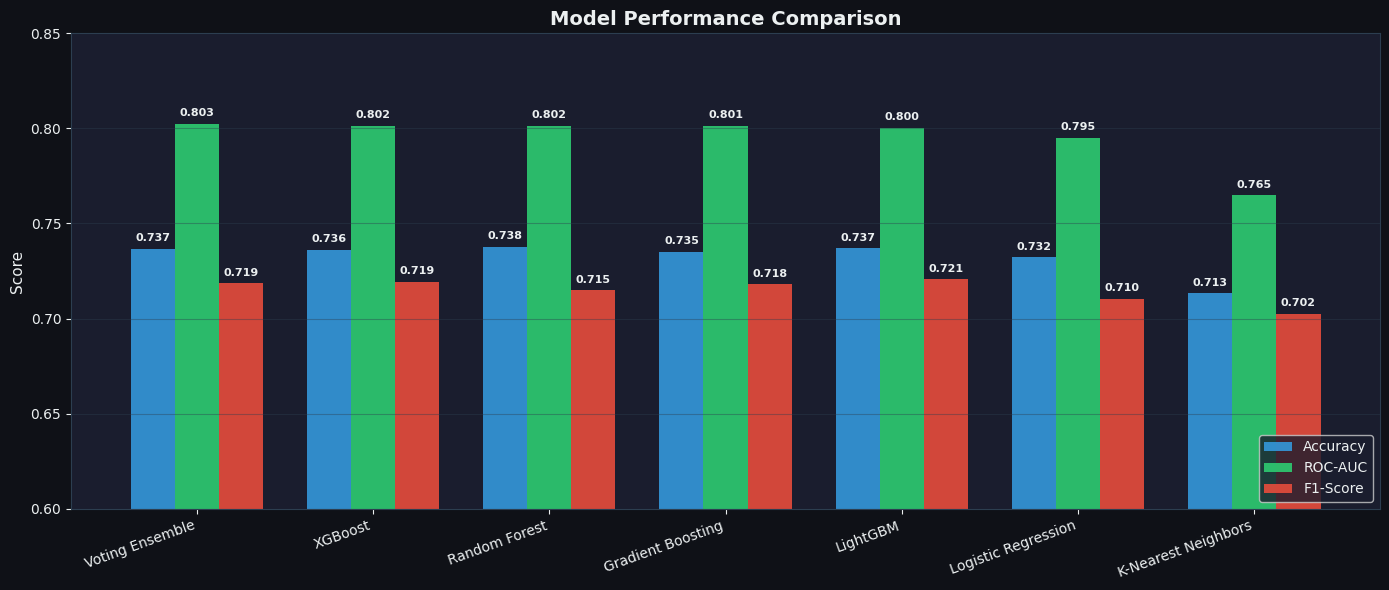

In [12]:
metrics_df = pd.DataFrame({
    k: {'Accuracy': v['acc'], 'ROC-AUC': v['roc_auc'], 'F1-Score': v['f1']}
    for k, v in results.items()
}).T.sort_values('ROC-AUC', ascending=False)

display(metrics_df.style.background_gradient(cmap='YlGn').format('{:.4f}'))

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor(BG_COLOR)
x = np.arange(len(metrics_df))
w = 0.25
b1 = ax.bar(x - w, metrics_df['Accuracy'], w, label='Accuracy', color='#3498DB', alpha=0.9)
b2 = ax.bar(x,     metrics_df['ROC-AUC'],  w, label='ROC-AUC',  color='#2ECC71', alpha=0.9)
b3 = ax.bar(x + w, metrics_df['F1-Score'], w, label='F1-Score', color='#E74C3C', alpha=0.9)

for bars in [b1, b2, b3]:
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.003,
                f'{b.get_height():.3f}', ha='center', va='bottom',
                fontsize=8, color=TEXT_COLOR, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(metrics_df.index, rotation=20, ha='right', fontsize=10)
ax.set_ylim(0.60, 0.85)
ax.set_ylabel('Score'); ax.set_title('Model Performance Comparison', fontweight='bold', fontsize=14)
ax.legend(loc='lower right'); ax.grid(True, axis='y')
plt.tight_layout()
plt.show()


## 8.2. ROC & Precision-Recall Curves

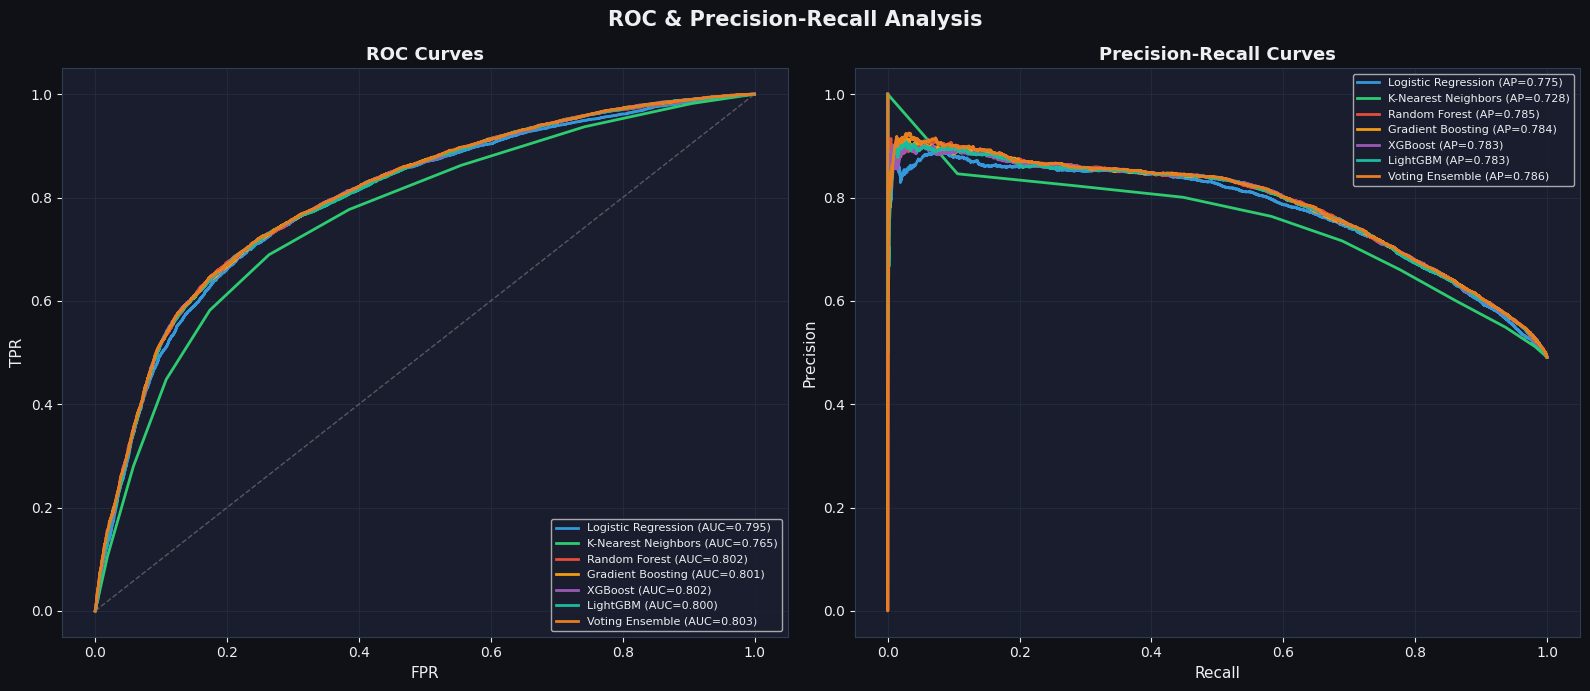

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor(BG_COLOR)

colors_roc = ['#3498DB','#2ECC71','#E74C3C','#F39C12','#9B59B6','#1ABC9C','#E67E22']

for (name, res), color in zip(results.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    axes[0].plot(fpr, tpr, color=color, lw=2,
                 label=f"{name} (AUC={res['roc_auc']:.3f})")

axes[0].plot([0,1],[0,1],'--', color='gray', lw=1, alpha=0.6)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC Curves', fontweight='bold')
axes[0].legend(loc='lower right', fontsize=8); axes[0].grid(True)

for (name, res), color in zip(results.items(), colors_roc):
    prec, rec, _ = precision_recall_curve(y_test, res['y_prob'])
    ap = average_precision_score(y_test, res['y_prob'])
    axes[1].plot(rec, prec, color=color, lw=2, label=f"{name} (AP={ap:.3f})")

axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves', fontweight='bold')
axes[1].legend(loc='upper right', fontsize=8); axes[1].grid(True)

plt.suptitle('ROC & Precision-Recall Analysis', fontsize=15, fontweight='bold', color=TEXT_COLOR)
plt.tight_layout()
plt.show()


## 8.3. Confusion Matrices — Top 4 Models

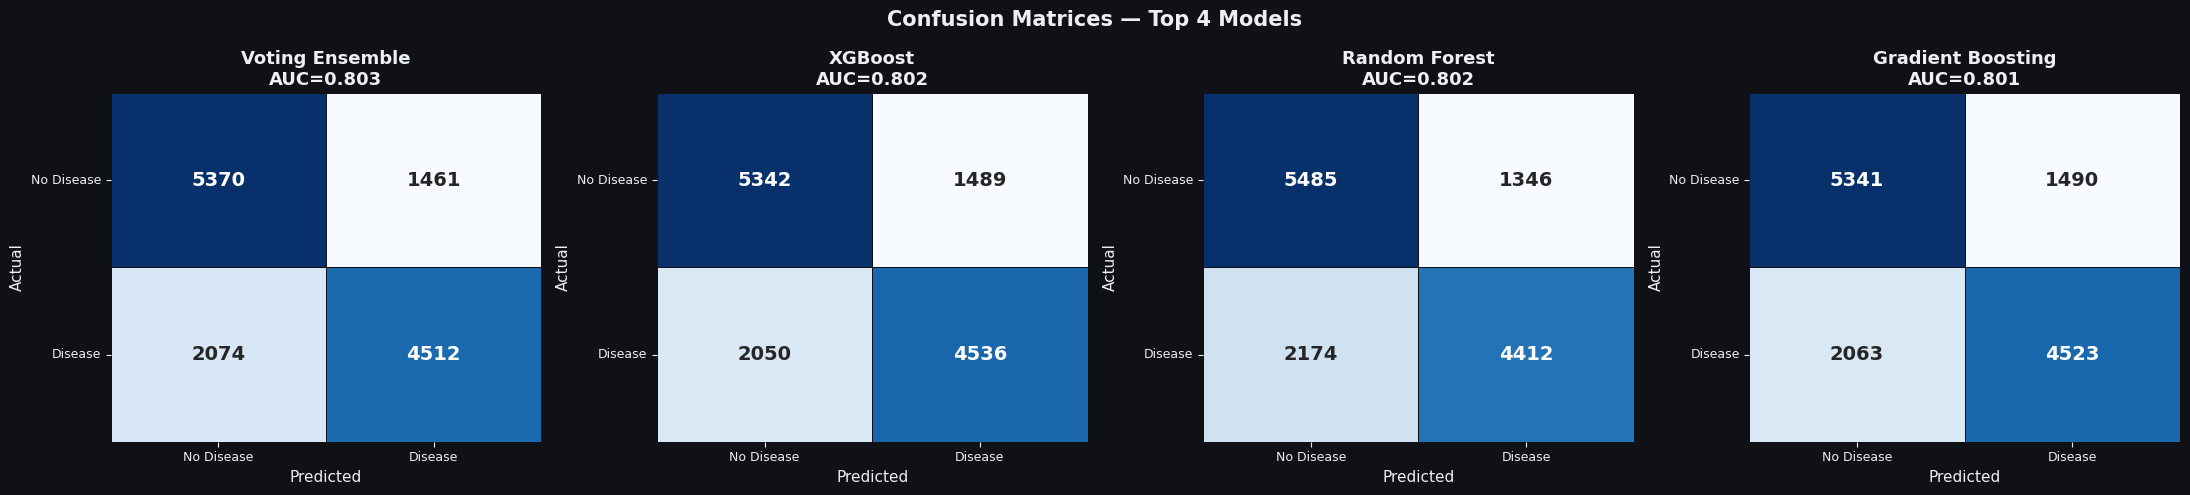

In [14]:
top4 = sorted(results, key=lambda k: results[k]['roc_auc'], reverse=True)[:4]
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.patch.set_facecolor(BG_COLOR)
fig.suptitle('Confusion Matrices — Top 4 Models', fontsize=15,
             fontweight='bold', color=TEXT_COLOR)

for ax, name in zip(axes, top4):
    cm = confusion_matrix(y_test, results[name]['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                linewidths=0.5, linecolor=BG_COLOR, cbar=False,
                annot_kws={'size': 14, 'weight': 'bold'})
    ax.set_title(f"{name}\nAUC={results[name]['roc_auc']:.3f}", fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_xticklabels(['No Disease', 'Disease'], fontsize=9)
    ax.set_yticklabels(['No Disease', 'Disease'], fontsize=9, rotation=0)

plt.tight_layout()
plt.show()


## 8.4. Feature Importance — XGBoost

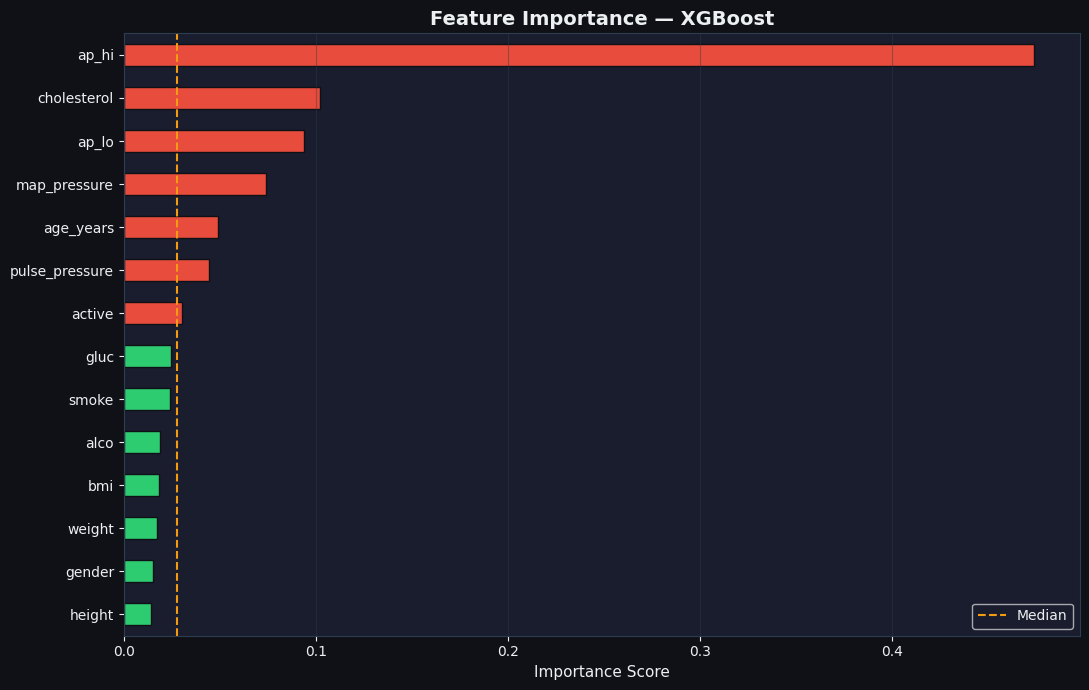

In [15]:
xgb_model = results['XGBoost']['model']
importances = pd.Series(xgb_model.feature_importances_, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor(BG_COLOR)
colors_fi = [PALETTE[1] if v > importances.median() else PALETTE[0] for v in importances]
importances.plot(kind='barh', ax=ax, color=colors_fi, edgecolor=BG_COLOR)
ax.set_title('Feature Importance — XGBoost', fontweight='bold', fontsize=14)
ax.set_xlabel('Importance Score')
ax.axvline(importances.median(), color='#F39C12', linestyle='--', lw=1.5, label='Median')
ax.legend(); ax.grid(True, axis='x')
plt.tight_layout()
plt.show()


## 9. Final Summary

In [16]:
best = max(results, key=lambda k: results[k]['roc_auc'])
r    = results[best]

print("=" * 55)
print("  FINAL RESULTS SUMMARY")
print("=" * 55)

summary = pd.DataFrame({
    k: {'Accuracy': v['acc'], 'ROC-AUC': v['roc_auc'], 'F1-Score': v['f1']}
    for k, v in results.items()
}).T.sort_values('ROC-AUC', ascending=False)

display(summary.style.background_gradient(cmap='YlGn').format('{:.4f}'))

print(f"\n🥇 Best Model  : {best}")
print(f"   Accuracy    : {r['acc']:.4f}")
print(f"   ROC-AUC     : {r['roc_auc']:.4f}")
print(f"   F1-Score    : {r['f1']:.4f}")

print(f"\n📋 Classification Report — {best}:")
print(classification_report(y_test, r['y_pred'],
                             target_names=['No Disease', 'Has Disease']))


  FINAL RESULTS SUMMARY


,Accuracy,ROC-AUC,F1-Score
Voting Ensemble,0.7365,0.8025,0.7185
XGBoost,0.7362,0.8015,0.7194
Random Forest,0.7376,0.8015,0.7148
Gradient Boosting,0.7352,0.8014,0.7180
LightGBM,0.7370,0.8004,0.7207
Logistic Regression,0.7322,0.7950,0.7105
K-Nearest Neighbors,0.7133,0.7649,0.7024



🥇 Best Model  : Voting Ensemble
   Accuracy    : 0.7365
   ROC-AUC     : 0.8025
   F1-Score    : 0.7185

📋 Classification Report — Voting Ensemble:
              precision    recall  f1-score   support

  No Disease       0.72      0.79      0.75      6831
 Has Disease       0.76      0.69      0.72      6586

    accuracy                           0.74     13417
   macro avg       0.74      0.74      0.74     13417
weighted avg       0.74      0.74      0.74     13417

